# I did some different preprocessing


so please see the process tfrecords file

## Now radius starts

In [1]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
from torch_cluster import radius_graph, radius
from dataclasses import dataclass
from enum import IntEnum


# CHANGE THIS
dataset_path = Path("datasets/deforming_plate/train.pth")
t = 100

In [2]:
@dataclass
class DeformingPlateSample:
    "one sample is one trajectory"

    sample_idx: int
    mesh_pos: torch.Tensor
    world_pos: torch.Tensor
    cells: torch.Tensor
    node_type: torch.Tensor
    stress: torch.Tensor

    def get_timestep(self, time_idx: int) -> "DeformingPlateSample":
        return self.__class__(
            sample_idx=self.sample_idx,
            mesh_pos=self.mesh_pos,
            world_pos=self.world_pos[time_idx],
            cells=self.cells,
            node_type=self.node_type,
            stress=self.stress[time_idx],
        )


class MeshGraphNetNodeType(IntEnum):
    NORMAL_MESH_NODE = 0
    EXTERNAL_FORCE_MESH_NODE = 1
    FIXED_MESH_NODE = 3  # this might be 3, was not so clear in dataset


In [3]:
# load dataset
raw_dataset = torch.load(dataset_path)
trajectory = DeformingPlateSample(**raw_dataset[0])

In [4]:
# get t, t+1 samples and clone world pos, then put for the actuator, instead of position t, position t+1
time_step = trajectory.get_timestep(t)
time_step_plus_one = trajectory.get_timestep(t + 1)
node_type = time_step.node_type

world_pos = time_step.world_pos.clone()
world_pos[node_type == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE] = (
    time_step_plus_one.world_pos[
        time_step.node_type == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE
    ]
)

In [5]:
time_step.world_pos = world_pos

In [ ]:
from hierarchical.datasets.deforming_plate import DeformingPlateSample
from hierarchical.utils import MeshGraphNetNodeType

# Obtain mesh vs actuator world positions, then edge_radius_index is = radius which returns
def get_world_edges(s_t: DeformingPlateSample) -> torch.Tensor:  # shape [2, num_edges]
    """Get edges between mesh and actuator nodes based on world positions."""
    mesh_pos = s_t.world_pos[
        s_t.node_type != MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE
    ]
    actuator_pos = s_t.world_pos[
        s_t.node_type == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE
    ]
    edge_radius_index = radius(mesh_pos, actuator_pos, r=0.03, max_num_neighbors=32)
    # need to reindex back to original node indices
    mesh_indices = torch.nonzero(s_t.node_type != 1, as_tuple=False).squeeze()
    actuator_indices = torch.nonzero(s_t.node_type == 1, as_tuple=False).squeeze()

    # radius graph returns edges from y->x, so from actuator->mesh
    connected_actuator_indices = actuator_indices[edge_radius_index[0]]
    connected_mesh_indices = mesh_indices[edge_radius_index[1]]

    # make edges undirected by concatenating the reverse edges
    edge_index = torch.stack(
            torch.cat([connected_mesh_indices, connected_actuator_indices]),
            torch.cat([connected_actuator_indices, connected_mesh_indices]),
        ],
        dim=0,
    )
    return edge_index

In [7]:
# save plate world position and actuator world position
mesh = time_step.world_pos[
    time_step.node_type != MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE
].numpy()
actuator = time_step.world_pos[
    time_step.node_type == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE
].numpy()

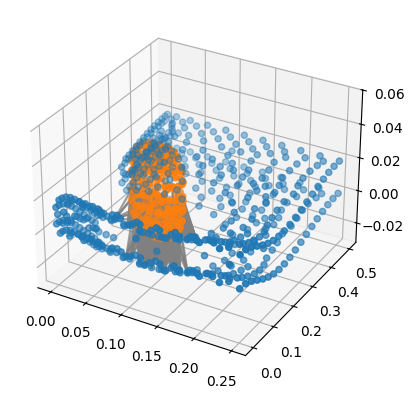

In [8]:
# enable for interactive vieweing
# %matplotlib widget
import matplotlib.pyplot as plt

# 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(mesh[:, 0], mesh[:, 1], mesh[:, 2])
ax.scatter(actuator[:, 0], actuator[:, 1], actuator[:, 2])
# plot an edge between all nodes in all_points[edge_index[0]], all_points[edge_index[1]]
edge_index = get_world_edges(time_step)
for i in range(len(edge_index[0])):
    p1 = time_step.world_pos[edge_index[0, i]]
    p2 = time_step.world_pos[edge_index[1, i]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color="gray", alpha=0.5)
plt.show()

## Compute all edges as world edges

You can also compute all edges with radius ignoring the mesh edges and that should also work, maybe even better for your Unet. The plot below should be laggy because it is so many edges

In [9]:
NEAREST_NEIGHBOR_RADIUS = 0.03


def get_gns_edges(
    node_types: torch.Tensor,  # shape [num_nodes]
    world_pos: torch.Tensor,  # world_pos where actuator nodes are at t+1
) -> torch.Tensor:  # shape [2, num_edges]
    world_edge_indices = radius_graph(
        world_pos, r=NEAREST_NEIGHBOR_RADIUS, max_num_neighbors=32
    )
    actuator_actuator_mask = torch.logical_and(
        node_types[world_edge_indices[0]]
        == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE,
        node_types[world_edge_indices[1]]
        == MeshGraphNetNodeType.EXTERNAL_FORCE_MESH_NODE,
    )

    edge_index = world_edge_indices[:, ~actuator_actuator_mask]
    full_edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
    return full_edge_index


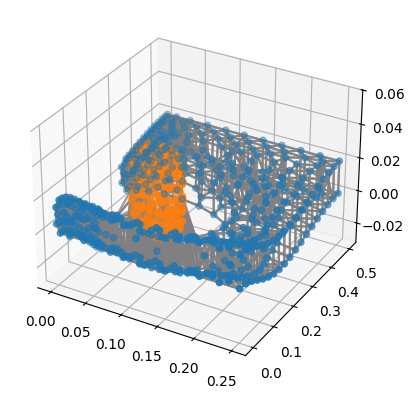

In [10]:
# enable for interactive vieweing
# %matplotlib widget

# 3d plot
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(mesh[:, 0], mesh[:, 1], mesh[:, 2])
ax.scatter(actuator[:, 0], actuator[:, 1], actuator[:, 2])
# plot an edge between all nodes in all_points[edge_index[0]], all_points[edge_index[1]]
edge_index = get_gns_edges(time_step.node_type, time_step.world_pos)
for i in range(len(edge_index[0])):
    p1 = time_step.world_pos[edge_index[0, i]]
    p2 = time_step.world_pos[edge_index[1, i]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color="gray", alpha=0.5)
plt.show()